# RSO-112: Analyse thermal and stability indicators during Dome louver testing

During the shutdown period (31.1. -14.2) we run multiple versions (different louver configurations) of the BLOCK-T679. Even though we were not on sky and we don’t have the IQ data, we would like to see the inside dome temperature response for different louvers configurations. 

Analyze dome and telescope thermal response during the 6-louver experimental campaigns, focusing on temperature coupling and ventilation behavior in the absence of image-quality (FWHM) indicators.

**Descripcion**

Create a small set of easy-to-interpret temperature indicators that describe how the dome and telescope behave thermally during each louvers configuration.

 

**Expected results:**

New variables:

inside vs outside temperature difference

telescope vs outside temperature difference

temperature gradient across the telescope sensors (111-113)

Table: basic statistics per configuration (average, variation)

Plots: simple box or line plots showing how these indicators change between configurations

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns

from lsst.summit.utils.efdUtils import getEfdData, makeEfdClient
from lsst.summit.utils.tmaUtils import TMAEventMaker, TMAState

In [2]:
t_start_period = Time("2026-01-31T00:00:00Z", scale="utc")
t_end_period = Time("2026-02-15T00:00:00Z", scale="utc")

efd_client = makeEfdClient()

In [3]:
# make a list of all topics in the EFD related to MTMount
topics = await efd_client.get_topics()
for topic in topics:
    if 'ESS' in topic:
        print(topic)

lsst.sal.ESS.accelerometer
lsst.sal.ESS.accelerometerPSD
lsst.sal.ESS.ackcmd
lsst.sal.ESS.agcGenset150
lsst.sal.ESS.airFlow
lsst.sal.ESS.airTurbulence
lsst.sal.ESS.command_disable
lsst.sal.ESS.command_enable
lsst.sal.ESS.command_enterControl
lsst.sal.ESS.command_exitControl
lsst.sal.ESS.command_setLogLevel
lsst.sal.ESS.command_standby
lsst.sal.ESS.command_start
lsst.sal.ESS.dewPoint
lsst.sal.ESS.earthquakeBroadBandHighGain
lsst.sal.ESS.earthquakeBroadBandLowGain
lsst.sal.ESS.earthquakeHighBroadBandHighGain
lsst.sal.ESS.earthquakeHighBroadBandLowGain
lsst.sal.ESS.earthquakeLongPeriodHighGain
lsst.sal.ESS.earthquakeLongPeriodLowGain
lsst.sal.ESS.earthquakeUltraLongPeriodHighGain
lsst.sal.ESS.earthquakeVeryLongPeriodHighGain
lsst.sal.ESS.electricFieldStrength
lsst.sal.ESS.hx85a
lsst.sal.ESS.hx85ba
lsst.sal.ESS.lightningStrikeStatus
lsst.sal.ESS.logevent_appliedSettingsMatchStart
lsst.sal.ESS.logevent_authList
lsst.sal.ESS.logevent_configurationApplied
lsst.sal.ESS.logevent_configurationsA

# Queries

In [4]:
def query_setlouvers(start, end):
    df_louvers = getEfdData(
        client=efd_client,
        topic="lsst.sal.MTDome.command_setLouvers",
        columns=["*"],
        begin=start,
        end=end,
    )

    return df_louvers

In [5]:
def query_essTemperature(start, end):
    df_esstemperature = getEfdData(
        client=efd_client,
        topic="lsst.sal.ESS.temperature",
        columns=['location', 'private_identity','sensorName', 'temperatureItem0','timestamp'],
        begin=start,
        end=end,
    )

    return df_esstemperature

# Configuration of louvers

In [6]:
df_setlouvers = query_setlouvers(t_start_period, t_end_period)

In [7]:
df_setlouvers.head()

,position0,position1,position10,position11,position12,position13,position14,position15,position16,position17,...,position8,position9,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp
2026-01-31 03:29:22.218386+00:00,0,0,0,30,30,0,0,0,0,0,...,0,0,1.769830e+09,Script:100102,1.769830e+09,37088,0,0afdb49a,1512418370,1.769830e+09
2026-01-31 04:31:45.671592+00:00,0,0,0,60,60,0,0,0,0,0,...,0,0,1.769834e+09,Script:100103,1.769834e+09,37176,0,0afdb49a,1512418370,1.769834e+09
2026-01-31 05:33:17.384032+00:00,0,0,0,100,100,0,0,0,0,0,...,0,0,1.769838e+09,Script:100104,1.769838e+09,37261,0,0afdb49a,1512418370,1.769838e+09
2026-02-01 03:15:59.271655+00:00,0,0,0,100,100,0,0,0,0,0,...,0,0,1.769916e+09,Script:100159,1.769916e+09,60487,0,0afdb49a,1512418370,1.769916e+09
2026-02-01 07:24:23.956772+00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,1.769931e+09,Script:100172,1.769931e+09,65874,0,0afdb49a,1512418370,1.769931e+09


In [8]:
# Copy current index into a new column before any merge
df_setlouvers['time_stamp'] = df_setlouvers.index

In [9]:
# Select all columns that start with "position"
position_cols = df_setlouvers.filter(regex=r'^position').columns

# Sort columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position', '')))

# Compute unique combinations
combination_counts = (
    df_setlouvers[position_cols]
    .value_counts()
    .reset_index(name='count')
)

# Create configuration ID (1 to N)
combination_counts['louvers_conf'] = range(1, len(combination_counts) + 1)

# Merge configuration ID back into original dataframe
df_setlouvers = df_setlouvers.merge(
    combination_counts[position_cols + ['louvers_conf']],
    on=position_cols,
    how='left'
)

print(f"Number of unique configurations detected: {len(combination_counts)}\n")

# Print configurations showing only non-zero positions
for _, row in combination_counts.iterrows():
    
    conf_id = row['louvers_conf']
    count = row['count']
    
    print(f"Configuration {conf_id} (appears {count} times):")
    
    # Extract position values
    config = row[position_cols]
    
    # Keep only non-zero values
    non_zero = config[config != 0]
    
    if len(non_zero) == 0:
        print("  All positions are 0")
    else:
        for col, val in non_zero.items():
            print(f"  {col}: {val}")
    
    print("-" * 40)

Number of unique configurations detected: 15

Configuration 1 (appears 17 times):
  position2: 100
  position11: 100
  position12: 100
  position20: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 2 (appears 14 times):
  position2: 10
  position11: 10
  position12: 10
  position20: 10
  position21: 10
  position29: 10
----------------------------------------
Configuration 3 (appears 5 times):
  position2: 50
  position11: 50
  position12: 50
  position20: 50
  position21: 50
  position29: 50
----------------------------------------
Configuration 4 (appears 4 times):
  position11: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 5 (appears 4 times):
  position2: 100
  position11: 100
  position12: 100
----------------------------------------
Configuration 6 (appears 4 times):
  position20: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 7 (appears 2

15 combinations have been made, varying the opening of the louvers: 2, 11, 12, 20, 21, and 29.

In [10]:
df_setlouvers.head()

,position0,position1,position10,position11,position12,position13,position14,position15,position16,position17,...,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,time_stamp,louvers_conf
0,0,0,0,30,30,0,0,0,0,0,...,1.769830e+09,Script:100102,1.769830e+09,37088,0,0afdb49a,1512418370,1.769830e+09,2026-01-31 03:29:22.218386+00:00,11
1,0,0,0,60,60,0,0,0,0,0,...,1.769834e+09,Script:100103,1.769834e+09,37176,0,0afdb49a,1512418370,1.769834e+09,2026-01-31 04:31:45.671592+00:00,13
2,0,0,0,100,100,0,0,0,0,0,...,1.769838e+09,Script:100104,1.769838e+09,37261,0,0afdb49a,1512418370,1.769838e+09,2026-01-31 05:33:17.384032+00:00,1
3,0,0,0,100,100,0,0,0,0,0,...,1.769916e+09,Script:100159,1.769916e+09,60487,0,0afdb49a,1512418370,1.769916e+09,2026-02-01 03:15:59.271655+00:00,1
4,0,0,0,0,0,0,0,0,0,0,...,1.769931e+09,Script:100172,1.769931e+09,65874,0,0afdb49a,1512418370,1.769931e+09,2026-02-01 07:24:23.956772+00:00,14


# ESS Temperature:  telescope sensors (111-113)

In [16]:
df_esstemperature = query_essTemperature(t_start_period, t_end_period)

In [17]:
df_esstemperature.head()

,location,private_identity,sensorName,temperatureItem0,timestamp
2026-01-31 00:00:00.024693+00:00,AT azimuth axis,ESS:201,AuxTel-ESS02,17.780001,1.769818e+09
2026-01-31 00:00:00.292090+00:00,"Unused, Tangent link A1, Tangent link A2, Tang...",ESS:106,M2-ESS01,NaN,1.769818e+09
2026-01-31 00:00:00.578568+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.220000,1.769818e+09
2026-01-31 00:00:00.578594+00:00,M1M3; RPi with sticker 4,ESS:113,M1M3-ESS03,14.670000,1.769818e+09
2026-01-31 00:00:00.586227+00:00,M2; RPi with sticker 1,ESS:112,M2-ESS02,14.930000,1.769818e+09


In [18]:
# Keep only the ESS identities with 111, 112 and 113
df_ess = df_esstemperature[
    df_esstemperature['private_identity'].isin(['ESS:111','ESS:112','ESS:113'])
].copy()

In [19]:
df_ess.head()

,location,private_identity,sensorName,temperatureItem0,timestamp
2026-01-31 00:00:00.578568+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.22,1.769818e+09
2026-01-31 00:00:00.578594+00:00,M1M3; RPi with sticker 4,ESS:113,M1M3-ESS03,14.67,1.769818e+09
2026-01-31 00:00:00.586227+00:00,M2; RPi with sticker 1,ESS:112,M2-ESS02,14.93,1.769818e+09
2026-01-31 00:00:01.959458+00:00,M1M3; RPi with sticker 4,ESS:113,M1M3-ESS03,14.67,1.769818e+09
2026-01-31 00:00:01.984884+00:00,M2; RPi with sticker 1,ESS:112,M2-ESS02,14.93,1.769818e+09


### Plots of telescope sensors (111-113)

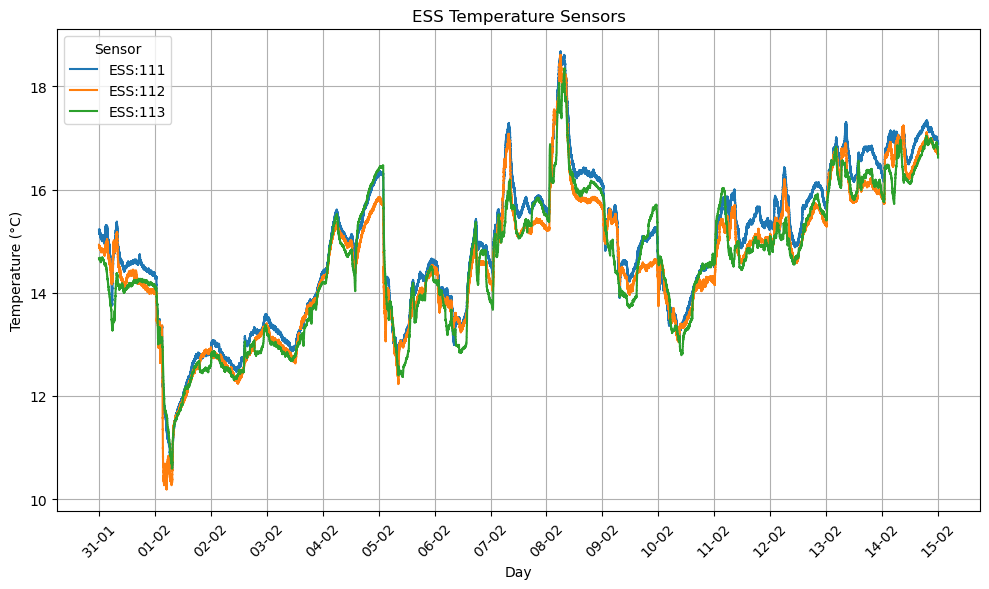

In [20]:
# Make a copy
df_ess = df_ess.copy()

# Convert timestamp to datetime
df_ess['time'] = pd.to_datetime(df_ess['timestamp'], unit='s')

# Sort by time
df_ess = df_ess.sort_values('time')

fig, ax = plt.subplots(figsize=(10,6))

for sensor_id, group in df_ess.groupby('private_identity'):
    ax.plot(group['time'], group['temperatureItem0'], label=sensor_id)

# Force one tick per day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Format showing day and month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.title("ESS Temperature Sensors")
plt.legend(title="Sensor")
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Cross with the louver settings

/tmp/ipykernel_4790/4174760114.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


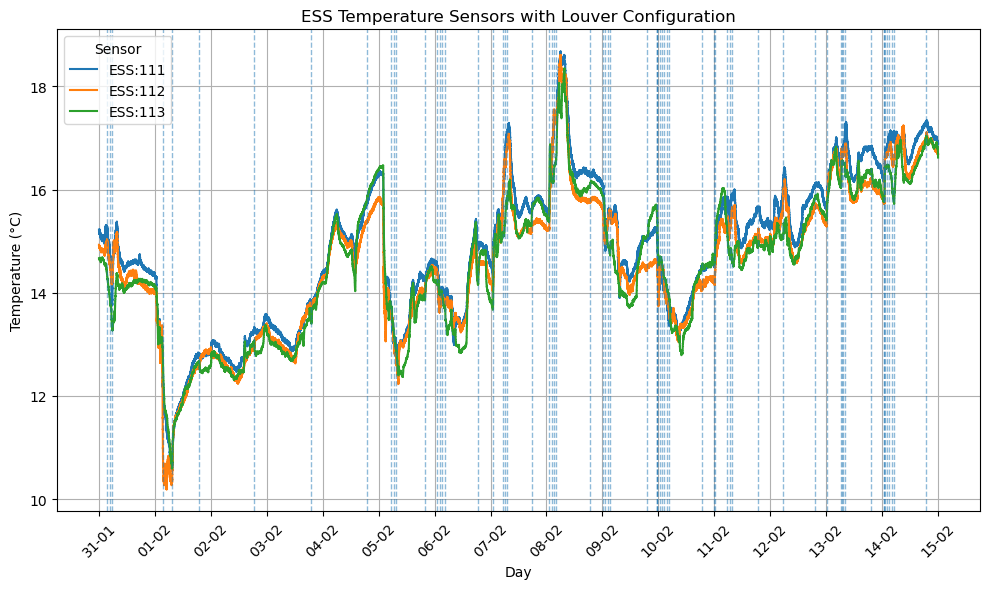

In [21]:
# Make copies to avoid modifying original slices
df_ess = df_ess.copy()
df_setlouvers = df_setlouvers.copy()

# Convert timestamps
df_ess['time'] = pd.to_datetime(df_ess['timestamp'], unit='s')
df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'])

# Sort data
df_ess = df_ess.sort_values('time')
df_setlouvers = df_setlouvers.sort_values('time_stamp')

fig, ax = plt.subplots(figsize=(10,6))

# Plot temperature lines
for sensor_id, group in df_ess.groupby('private_identity'):
    ax.plot(group['time'], group['temperatureItem0'], label=sensor_id)

# Add vertical lines for louver configuration changes
for t in df_setlouvers['time_stamp']:
    ax.axvline(t, linestyle='--', linewidth=1, alpha=0.5)

# One tick per day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.title("ESS Temperature Sensors with Louver Configuration")
plt.legend(title="Sensor")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [22]:
df_setlouvers['time_end'] = df_setlouvers['time_stamp'].shift(-1)
max_time = df_ess['time'].max()
df_setlouvers['time_end'] = df_setlouvers['time_end'].fillna(max_time)

In [23]:
# Column positions
position_cols = df_setlouvers.filter(regex=r'^position').columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

# Function to labels
def build_conf_label(row):
    config = row[position_cols]
    non_zero = config[config != 0]

    if len(non_zero) == 0:
        return f"Configuration {row['louvers_conf']}: all closed"

    lines = [f"Configuration {row['louvers_conf']}:"]
    for col, val in non_zero.items():
        lines.append(f"{col}: {int(val)}")
    return "\n".join(lines)

df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

/tmp/ipykernel_4790/895398979.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


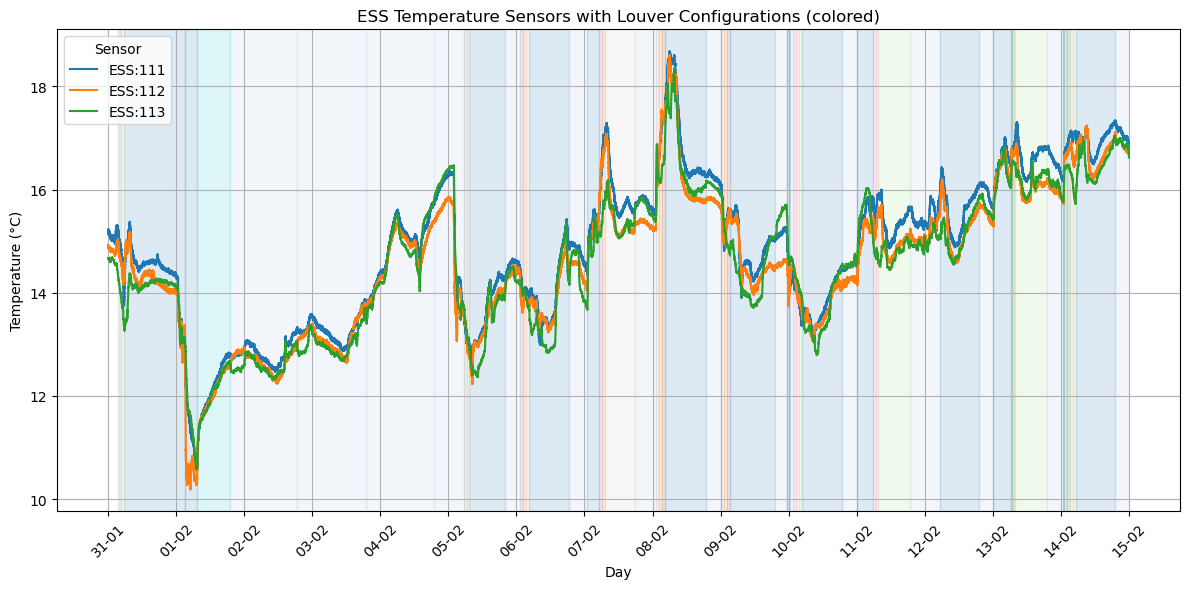

In [27]:
# Colormap for configuration
n_confs = df_setlouvers['louvers_conf'].nunique()
colors = plt.colormaps['tab20'].resampled(n_confs)

df_ess['time'] = pd.to_datetime(df_ess['time'], utc=True)
df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'], utc=True)
df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'], utc=True)

df_ess['time'] = df_ess['time'].dt.tz_convert(None)
df_setlouvers['time_stamp'] = df_setlouvers['time_stamp'].dt.tz_convert(None)
df_setlouvers['time_end'] = df_setlouvers['time_end'].dt.tz_convert(None)




fig, ax = plt.subplots(figsize=(12,6))

# --- Temperature Lines ---
for sensor_id, group in df_ess.groupby('private_identity'):
    ax.plot(group['time'], group['temperatureItem0'], label=sensor_id)

# --- Shading by configuration ---
for i, (_, row) in enumerate(df_setlouvers.iterrows()):
    start = row['time_stamp']
    end = row['time_end']
    conf_num = int(row['louvers_conf']) - 1 
    ax.axvspan(start, end, color=colors(conf_num), alpha=0.15)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.title("ESS Temperature Sensors with Louver Configurations (colored)")
plt.legend(title="Sensor")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

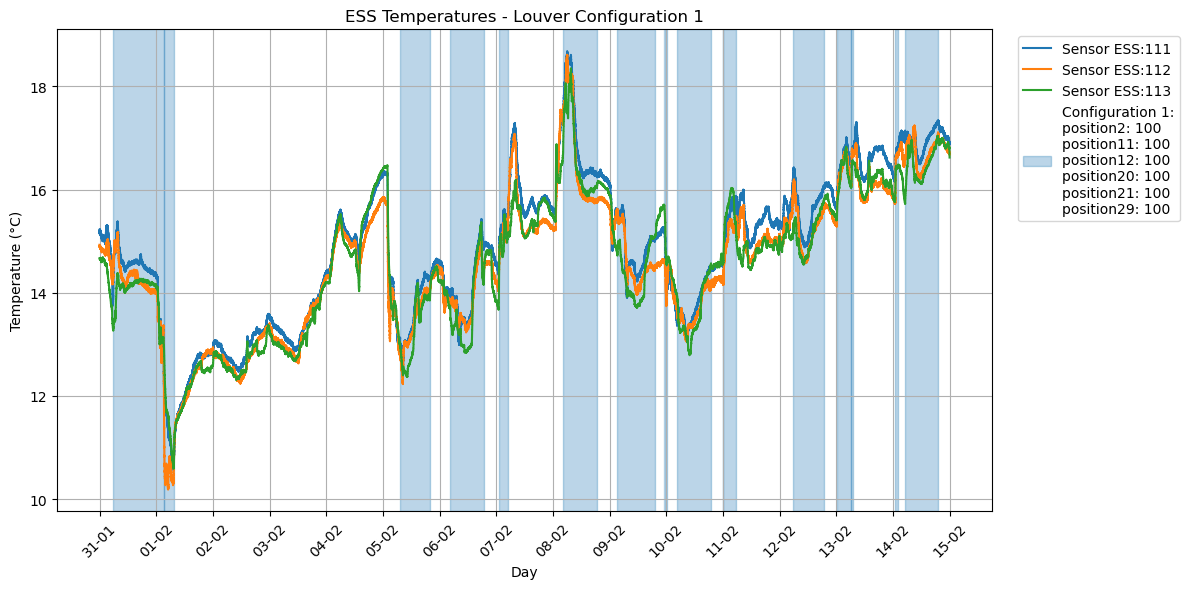

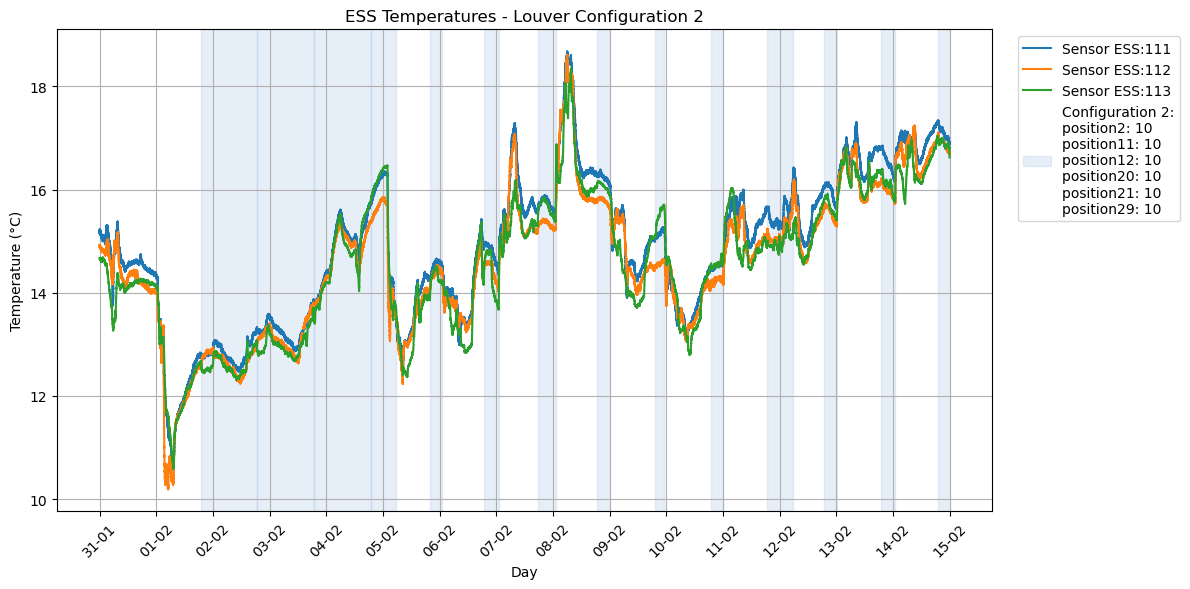

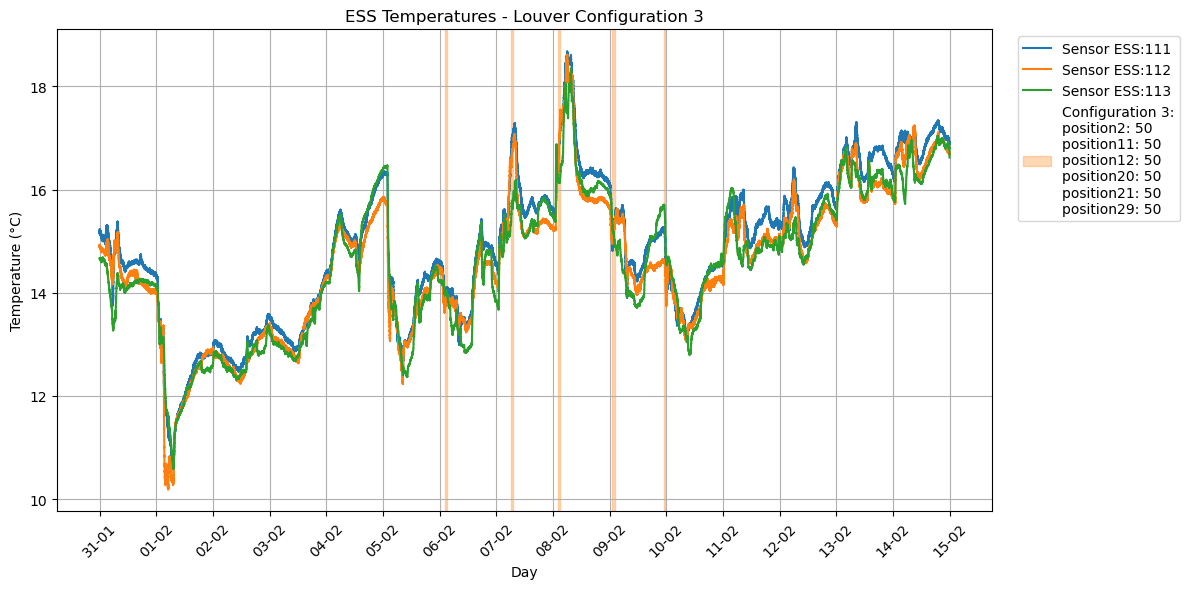

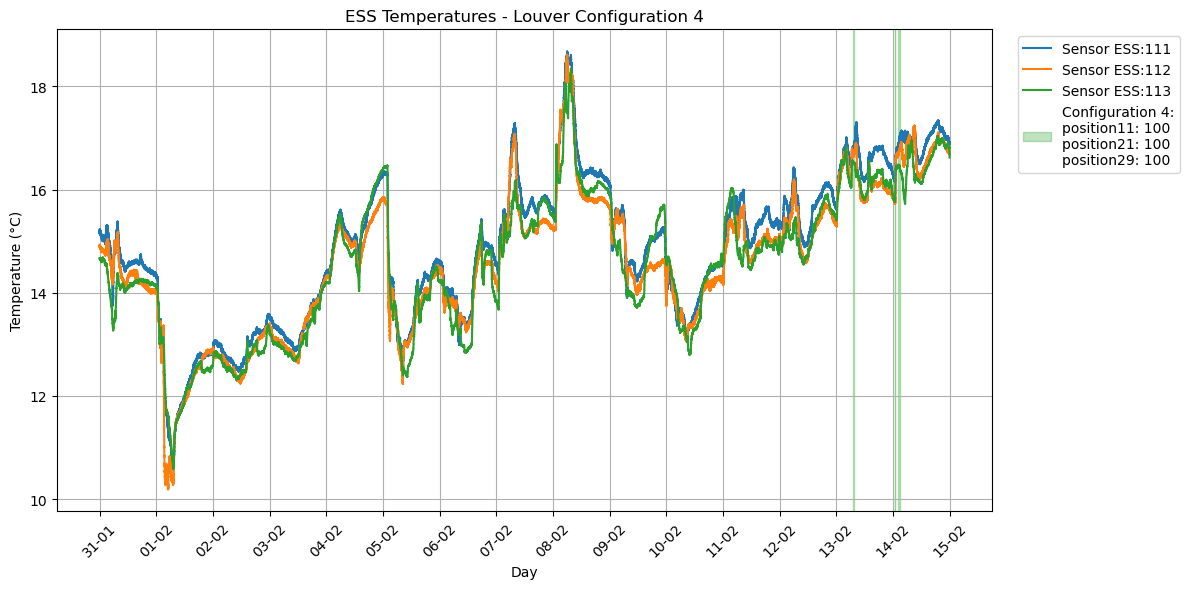

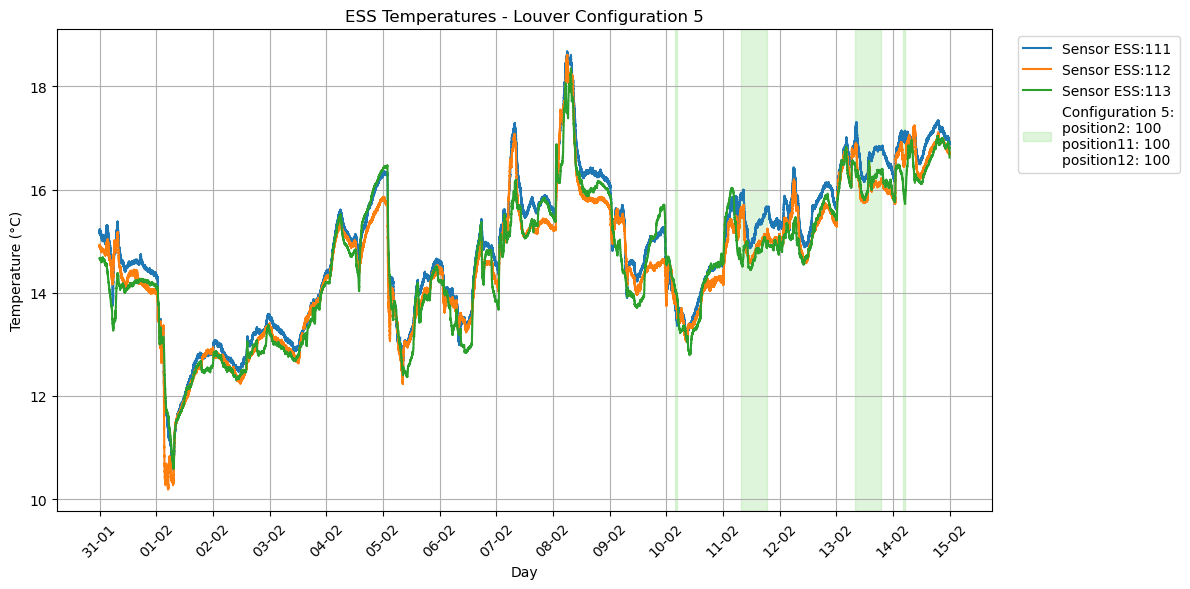

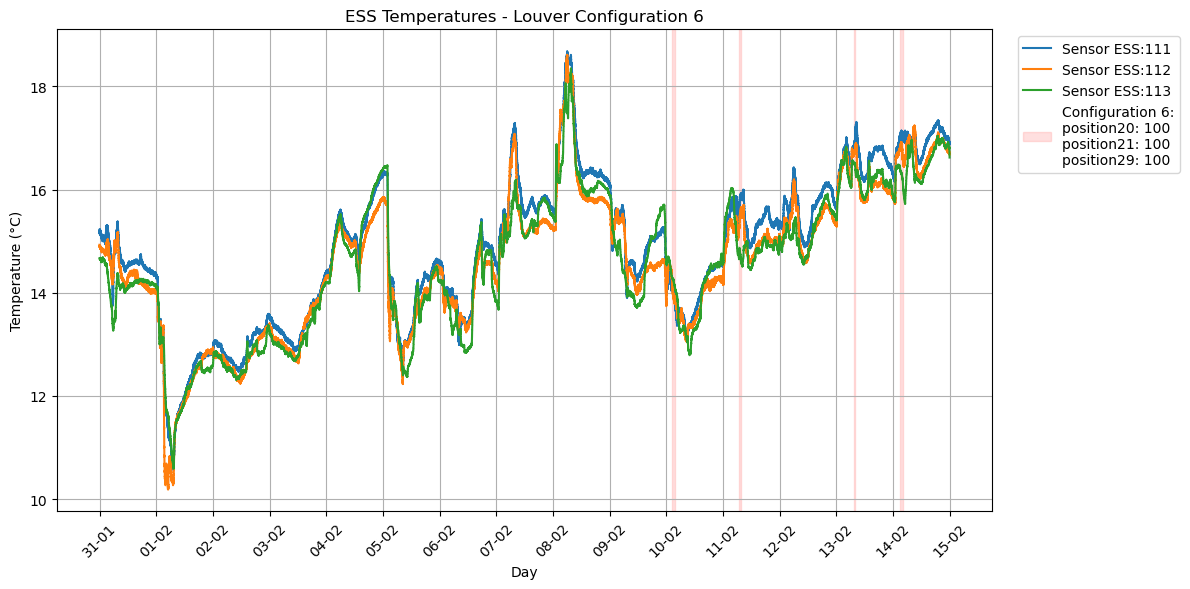

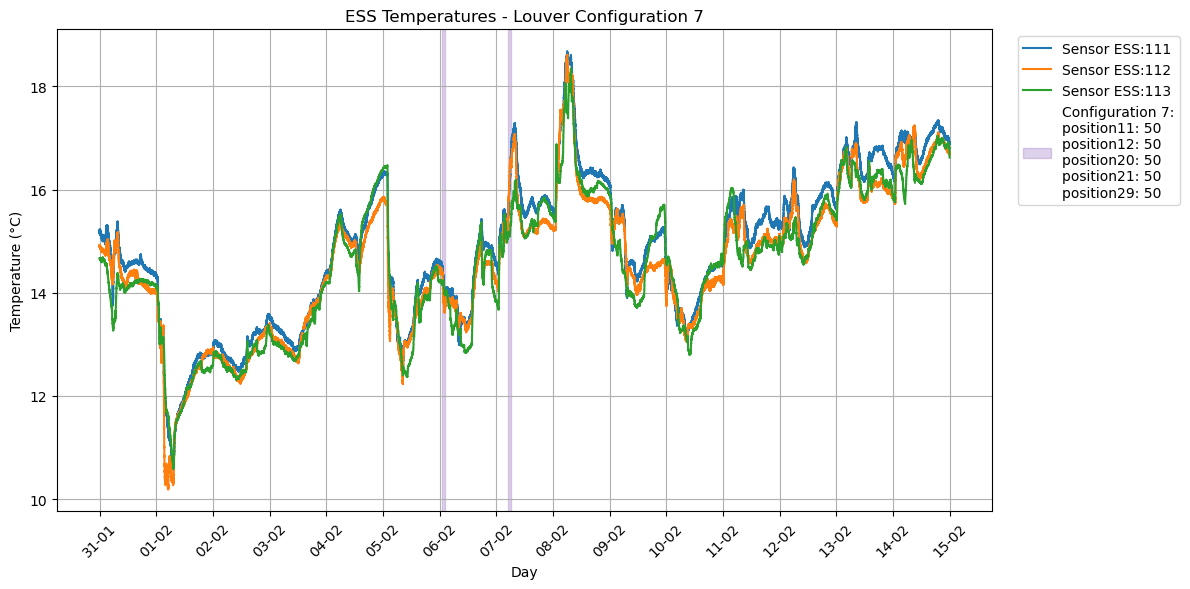

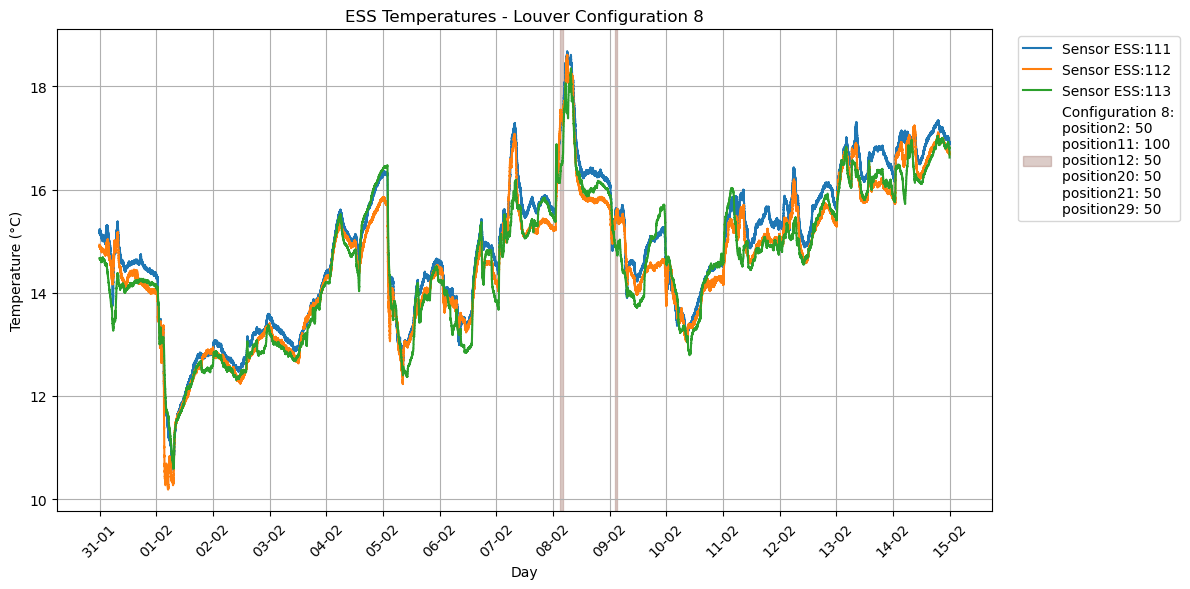

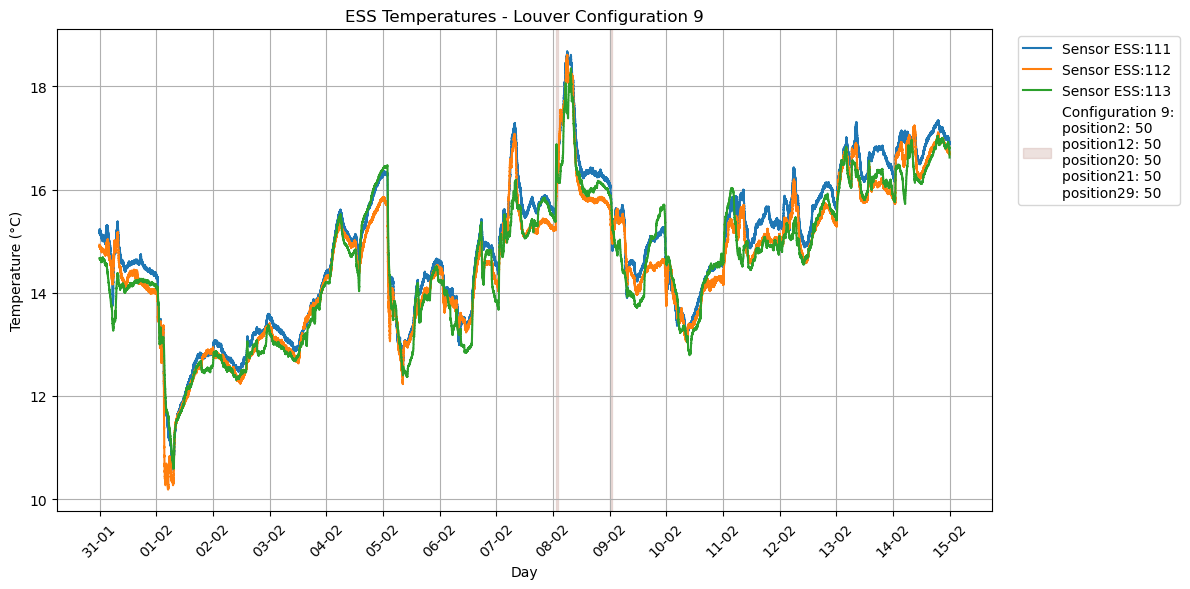

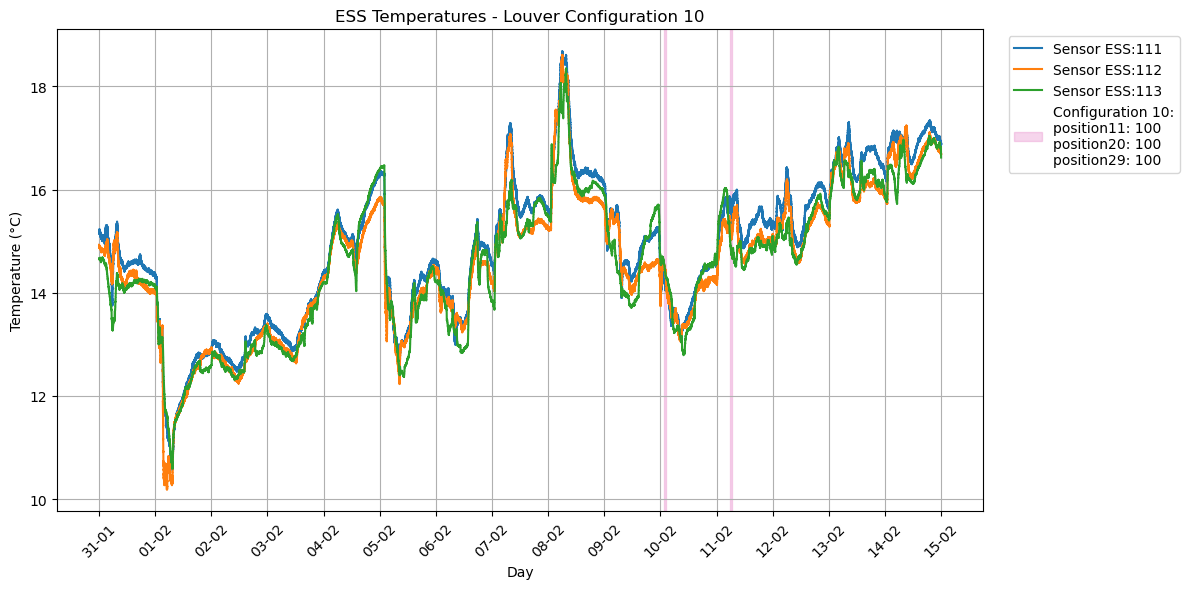

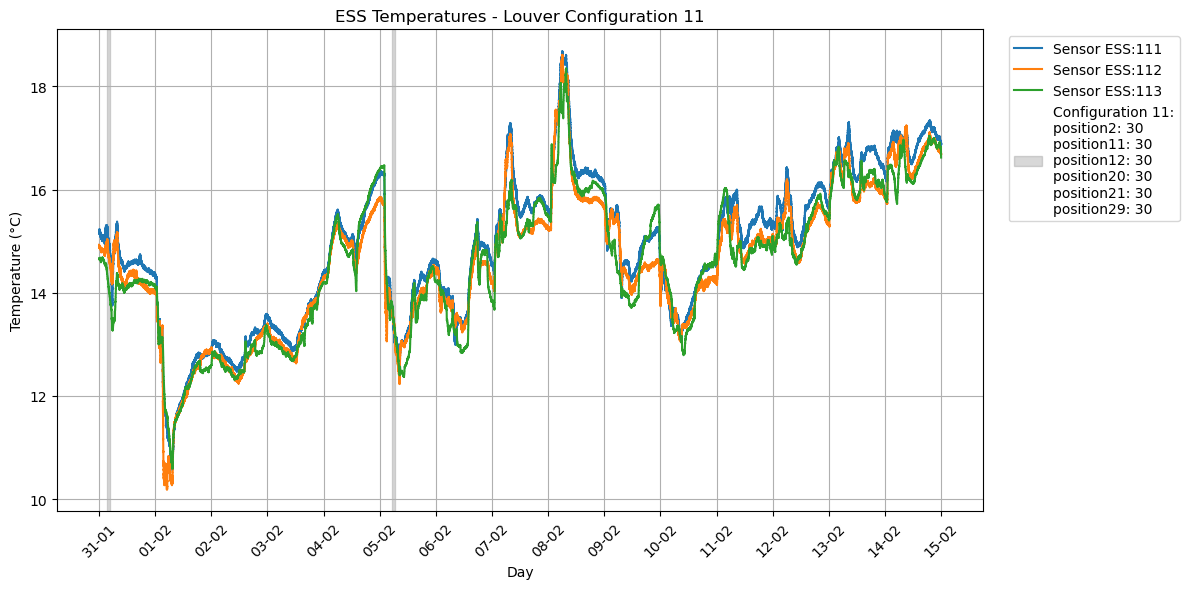

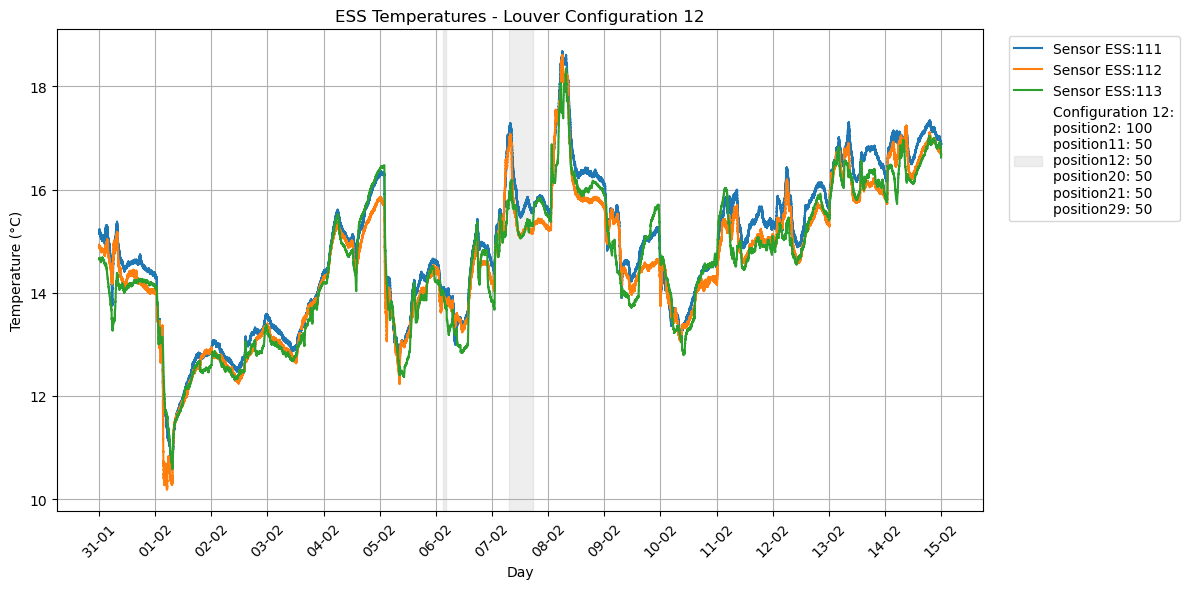

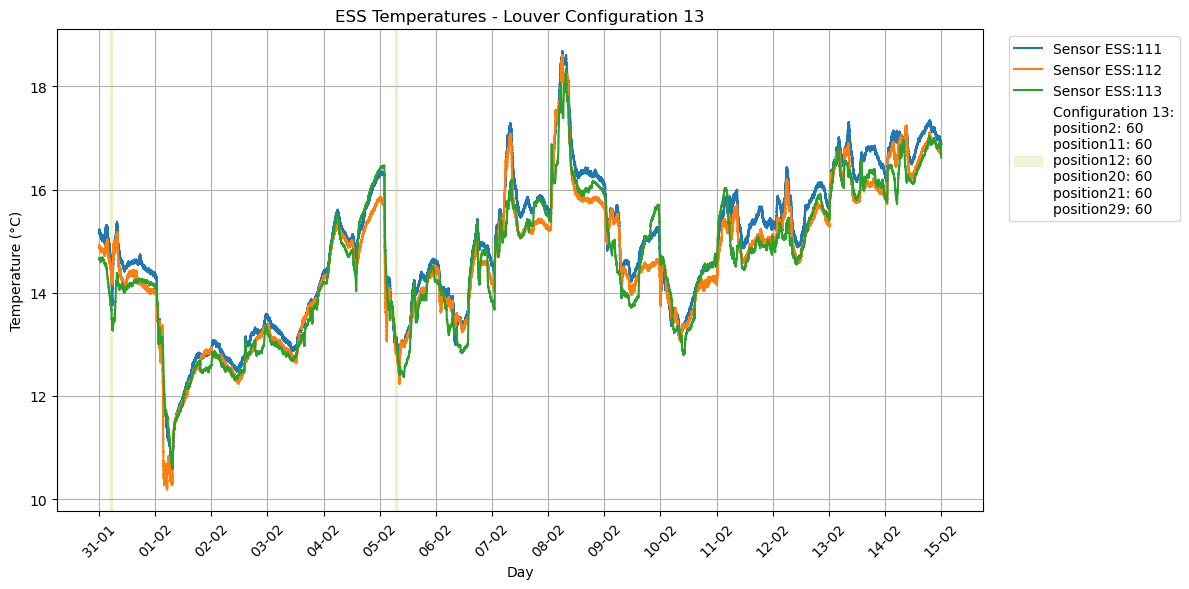

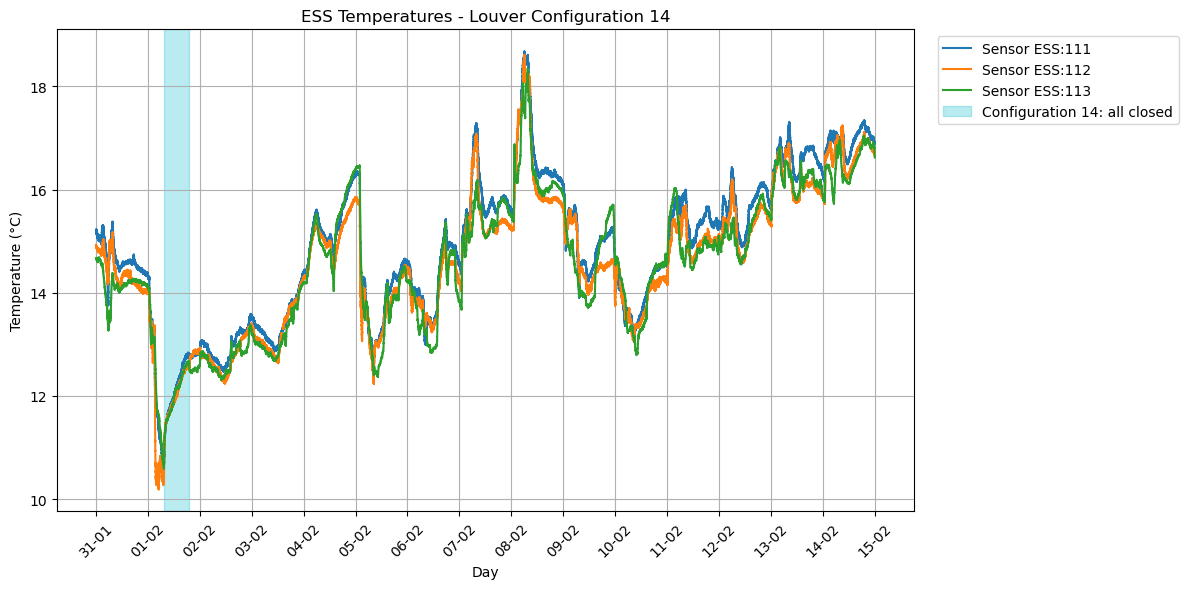

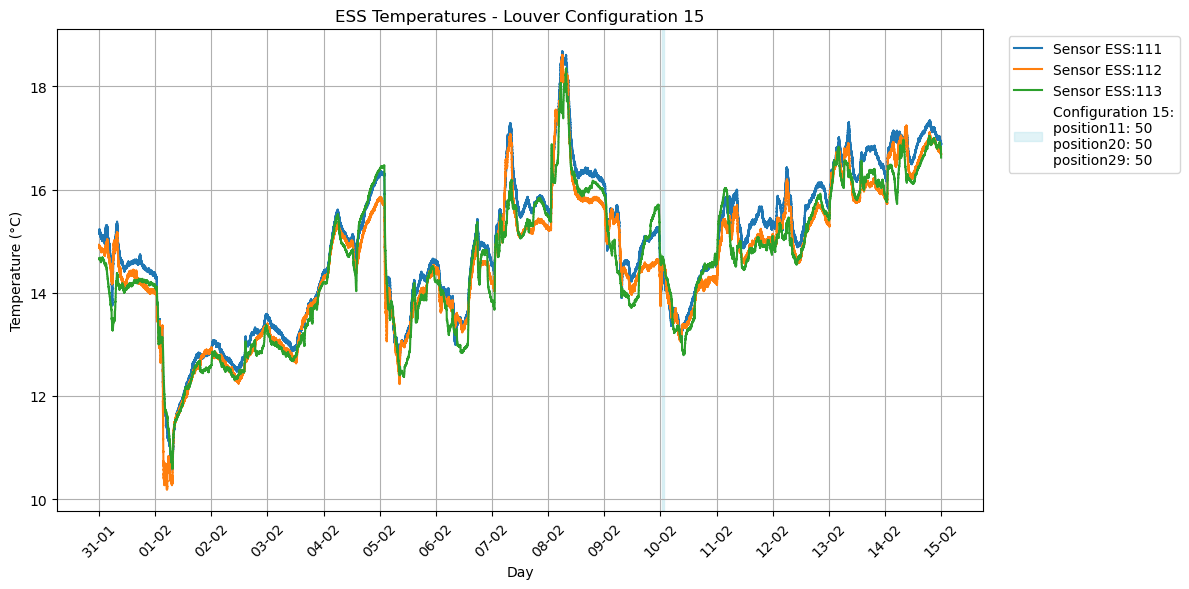

In [28]:
# Number of unique configuration
conf_ids = sorted(df_setlouvers['louvers_conf'].unique())
n_confs = len(conf_ids)

# Colormap by configuration
colors = plt.get_cmap('tab20', n_confs)

# Columns positions
position_cols = df_setlouvers.filter(regex=r'^position').columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

# Labels for configuration
def build_conf_label(row):
    config = row[position_cols]
    non_zero = config[config != 0]
    if len(non_zero) == 0:
        return f"Configuration {row['louvers_conf']}: all closed"
    lines = [f"Configuration {row['louvers_conf']}:"]
    for col, val in non_zero.items():
        lines.append(f"{col}: {int(val)}")
    return "\n".join(lines)

df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

for conf_num in conf_ids:

    fig, ax = plt.subplots(figsize=(12,6))
    
    for sensor_id, group in df_ess.groupby('private_identity'):
        ax.plot(group['time'], group['temperatureItem0'], label=f"Sensor {sensor_id}")
    
    # A plot for configuration
    conf_df = df_setlouvers[df_setlouvers['louvers_conf'] == conf_num]

    for i, (_, row) in enumerate(conf_df.iterrows()):
        start = row['time_stamp']
        end = row['time_end']
        label = row['conf_label']
        ax.axvspan(start, end, color=colors(int(conf_num)-1), alpha=0.3, label=label)
    
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

    plt.xlabel("Day")
    plt.ylabel("Temperature (°C)")
    plt.title(f"ESS Temperatures - Louver Configuration {conf_num}")
    
    # Avoid duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02,1), loc='upper left')
    
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Table: basic statistics per configuration (average, variation)

In [32]:
# Format of the times
df_ess['time'] = pd.to_datetime(df_ess['time'])
df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'])
df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'])

In [33]:
results = []

for _, conf in df_setlouvers.iterrows():

    start = conf['time_stamp']
    end = conf['time_end']
    conf_id = conf['louvers_conf']
    conf_label = conf['conf_label']

    # datos dentro del intervalo
    subset = df_ess[(df_ess['time'] >= start) & (df_ess['time'] <= end)]

    duration = (end - start).total_seconds()/60  # minutos

    for sensor, group in subset.groupby('private_identity'):

        temp = group['temperatureItem0']

        if len(temp) < 2:
            continue

        gradient = (temp.iloc[-1] - temp.iloc[0]) / duration

        results.append({
            "louvers_conf": conf_id,
            "conf_label": conf_label,
            "sensor": sensor,
            "duration_min": duration,
            "mean_temp": temp.mean(),
            "std_temp": temp.std(),
            "min_temp": temp.min(),
            "max_temp": temp.max(),
            "temp_range": temp.max() - temp.min(),
            "gradient_deg_per_min": gradient
        })

df_stats = pd.DataFrame(results)

In [42]:
df_stats

,louvers_conf,conf_label,sensor,duration_min,mean_temp,std_temp,min_temp,max_temp,temp_range,gradient_deg_per_min
0,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:111,62.390887,15.032874,0.096974,14.880000,15.290000,0.410000,-0.005610
1,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:112,62.390887,14.757299,0.117849,14.590000,15.030000,0.440000,-0.006571
2,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:113,62.390887,14.138166,0.120473,13.920000,14.350000,0.430000,-0.006892
3,13,Configuration 13:\nposition2: 60\nposition11: ...,ESS:111,61.528541,14.549212,0.300147,13.800000,14.910000,1.110000,-0.017553
4,13,Configuration 13:\nposition2: 60\nposition11: ...,ESS:112,61.528541,14.405139,0.144590,14.160000,14.630000,0.470000,-0.006989
...,...,...,...,...,...,...,...,...,...,...
187,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:112,829.880959,16.691019,0.269643,16.209999,17.240000,1.030001,0.000470
188,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:113,829.880959,16.468006,0.275535,15.720000,17.040001,1.320001,0.001579
189,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:111,300.687745,17.099529,0.112889,16.870001,17.340000,0.469999,-0.001397
190,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:112,300.687745,16.877187,0.097508,16.670000,17.110001,0.440001,-0.001197


In [36]:
# Separate in tables for louvers configuration
tables = {}

for conf in df_stats['louvers_conf'].unique():
    tables[conf] = df_stats[df_stats['louvers_conf']==conf]

In [39]:
# For example, to see configuration 1 for the 3 sensors and the stat each time this configuration is working
tables[1]

,louvers_conf,conf_label,sensor,duration_min,mean_temp,std_temp,min_temp,max_temp,temp_range,gradient_deg_per_min
6,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,1302.698127,14.414911,0.467087,12.250000,15.380000,3.130000,-0.001205
7,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:112,1302.698127,14.155035,0.447125,12.260000,15.170000,2.910000,-0.001482
8,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:113,1302.698127,14.013363,0.353626,12.950000,14.380000,1.430000,-0.000345
9,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,248.411419,11.309894,0.487439,10.570000,12.260000,1.690001,-0.006602
10,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:112,248.411419,10.537389,0.276777,10.190000,12.300000,2.110001,-0.007528
11,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:113,248.411419,11.488468,0.569200,10.590000,12.960000,2.370000,-0.009500
33,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,754.525691,13.653100,0.561874,12.580000,14.410000,1.830000,0.001643
34,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:112,754.525691,13.446083,0.494786,12.230000,14.100000,1.870001,0.001643
35,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:113,754.525691,13.263081,0.624321,12.370000,14.190000,1.820000,0.001352
48,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,864.180580,13.996189,0.661666,12.990000,15.430000,2.440001,0.001007


In [35]:
# Summary of the different configuration of louvers
df_summary = (
    df_stats
    .groupby(['louvers_conf','conf_label','sensor'])
    .agg({
        'duration_min':'mean',
        'mean_temp':'mean',
        'std_temp':'mean',
        'gradient_deg_per_min':'mean',
        'temp_range':'mean'
    })
    .reset_index()
)

In [38]:
df_summary

,louvers_conf,conf_label,sensor,duration_min,mean_temp,std_temp,gradient_deg_per_min,temp_range
0,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,505.193679,15.074207,0.350591,0.000745,1.362353
1,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:112,505.193679,14.789939,0.334691,0.002503,1.420588
2,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:113,505.193679,14.892156,0.364149,-0.000455,1.351177
3,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:111,613.659008,15.173715,0.224653,-0.000333,0.818571
4,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:112,613.659008,14.842245,0.203151,-0.000196,0.762143
5,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:113,613.659008,14.994399,0.257989,-0.000238,0.910000
6,3,Configuration 3:\nposition2: 50\nposition11: 5...,ESS:111,51.540518,15.641703,0.123200,0.003745,0.462000
7,3,Configuration 3:\nposition2: 50\nposition11: 5...,ESS:112,51.540518,15.442258,0.146558,0.005442,0.518000
8,3,Configuration 3:\nposition2: 50\nposition11: 5...,ESS:113,51.540518,15.291069,0.075083,-0.002527,0.270000
9,4,Configuration 4:\nposition11: 100\nposition21:...,ESS:111,24.927925,16.535487,0.036666,0.006969,0.142500


In [44]:
df_stats.columns

Index(['louvers_conf', 'conf_label', 'sensor', 'duration_min', 'mean_temp',
       'std_temp', 'min_temp', 'max_temp', 'temp_range',
       'gradient_deg_per_min'],
      dtype='object')

In [45]:
df_stats.head()

,louvers_conf,conf_label,sensor,duration_min,mean_temp,std_temp,min_temp,max_temp,temp_range,gradient_deg_per_min
0,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:111,62.390887,15.032874,0.096974,14.88,15.29,0.41,-0.005610
1,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:112,62.390887,14.757299,0.117849,14.59,15.03,0.44,-0.006571
2,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:113,62.390887,14.138166,0.120473,13.92,14.35,0.43,-0.006892
3,13,Configuration 13:\nposition2: 60\nposition11: ...,ESS:111,61.528541,14.549212,0.300147,13.80,14.91,1.11,-0.017553
4,13,Configuration 13:\nposition2: 60\nposition11: ...,ESS:112,61.528541,14.405139,0.144590,14.16,14.63,0.47,-0.006989


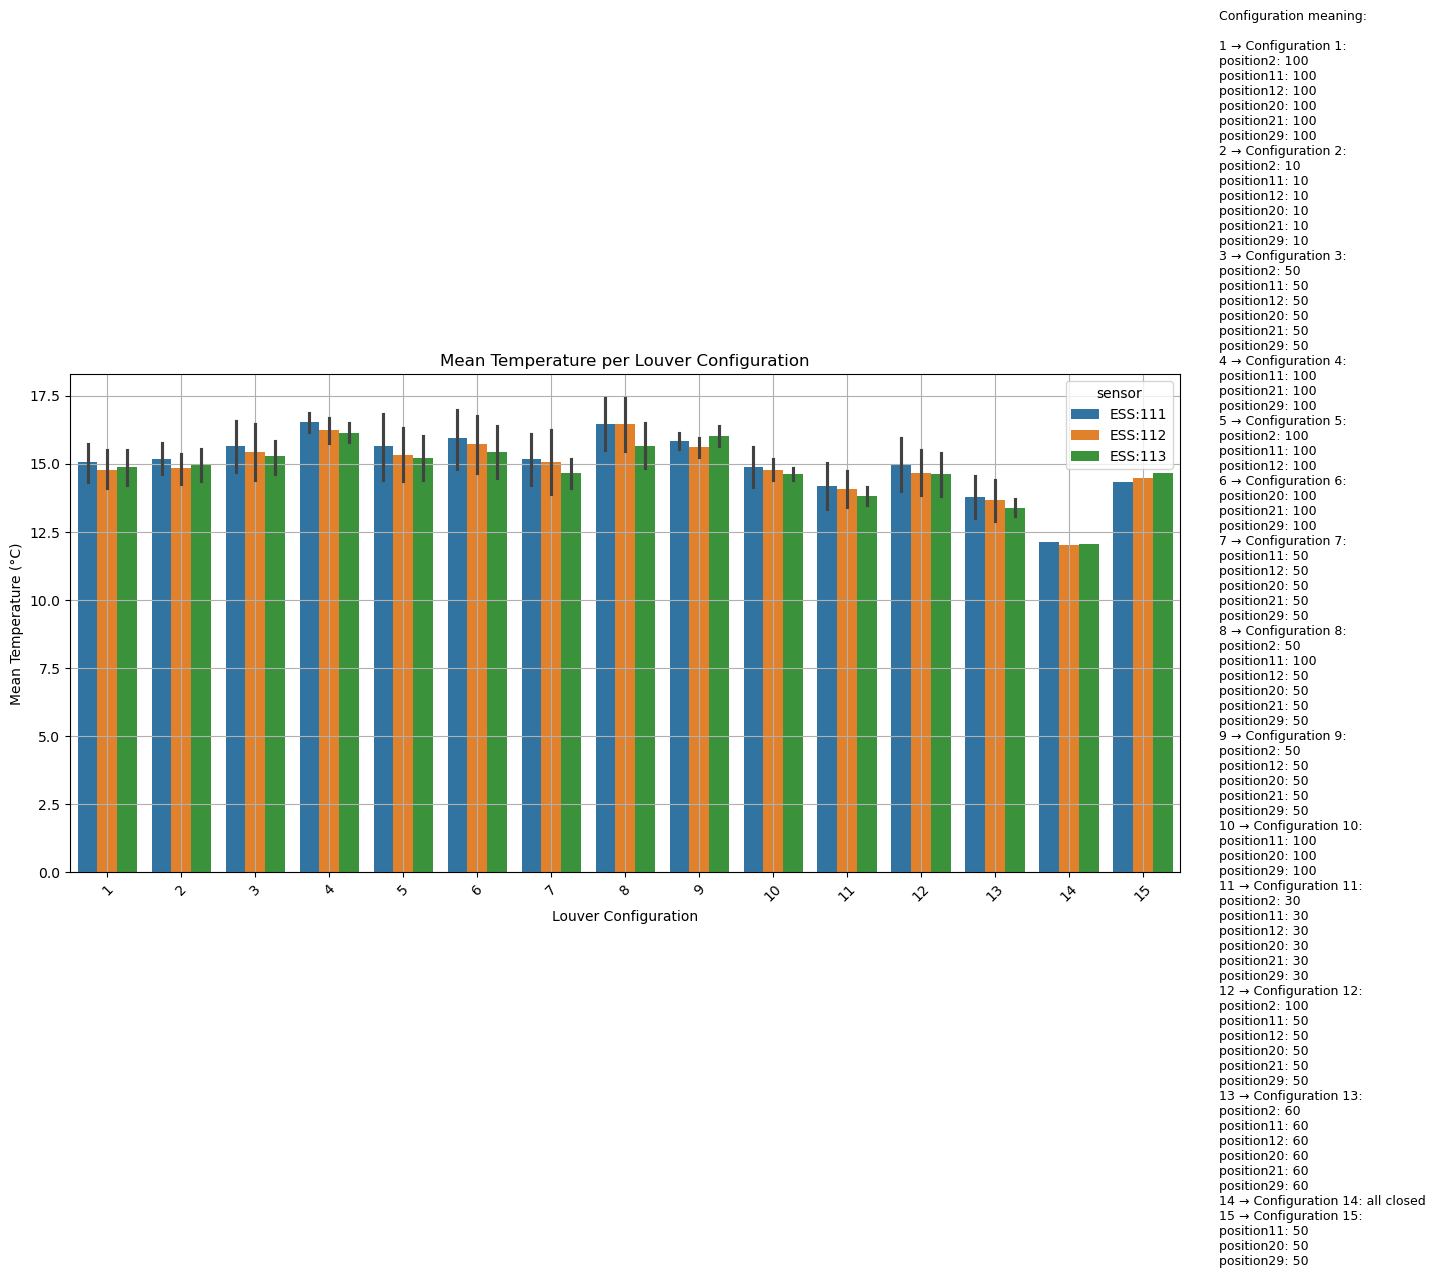

In [56]:
# Mean Temperature per Louver Configuration
# Shows which configuration leads to higher or lower temperatures

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_stats,
    x="louvers_conf",
    y="mean_temp",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Mean Temperature (°C)")
plt.title("Mean Temperature per Louver Configuration")

plt.xticks(rotation=45)
plt.grid(True)

# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)

plt.tight_layout()
plt.show()

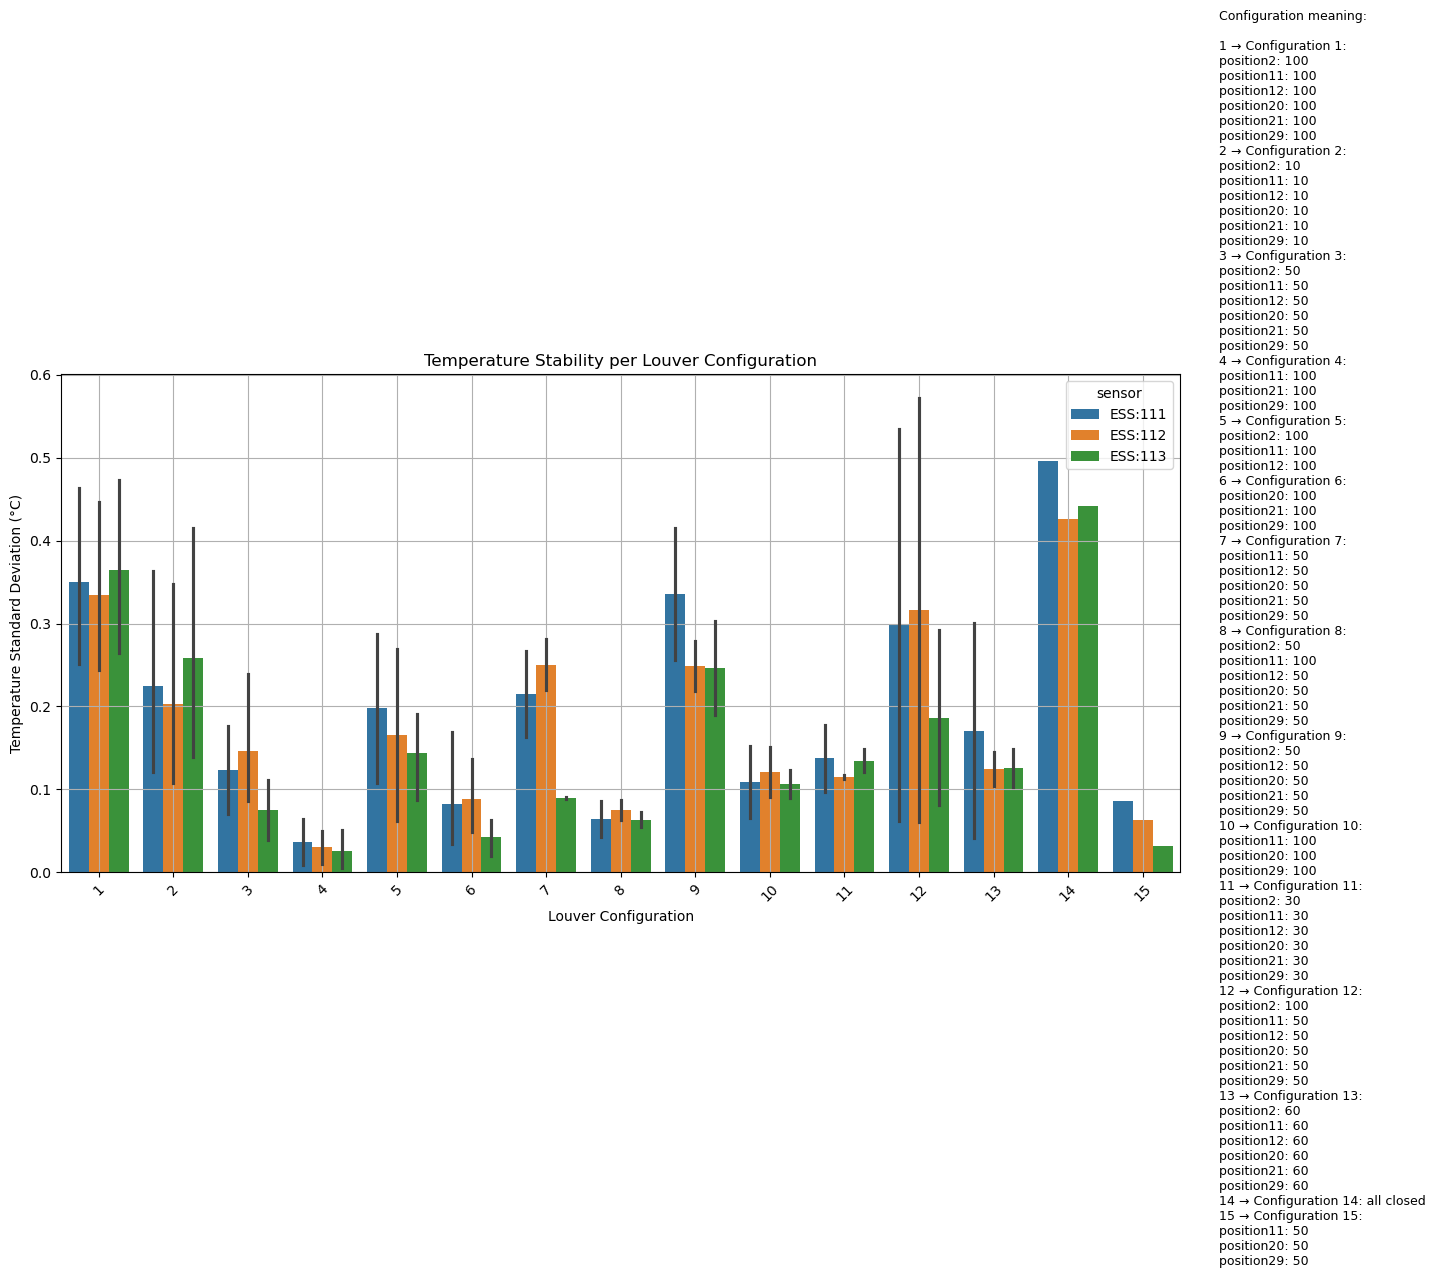

In [58]:
# Temperature Stability per Louver Configuration
# Lower standard deviation means more stable thermal behavior

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_stats,
    x="louvers_conf",
    y="std_temp",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Temperature Standard Deviation (°C)")
plt.title("Temperature Stability per Louver Configuration")
plt.xticks(rotation=45)
plt.grid(True)

# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)


plt.tight_layout()
plt.show()

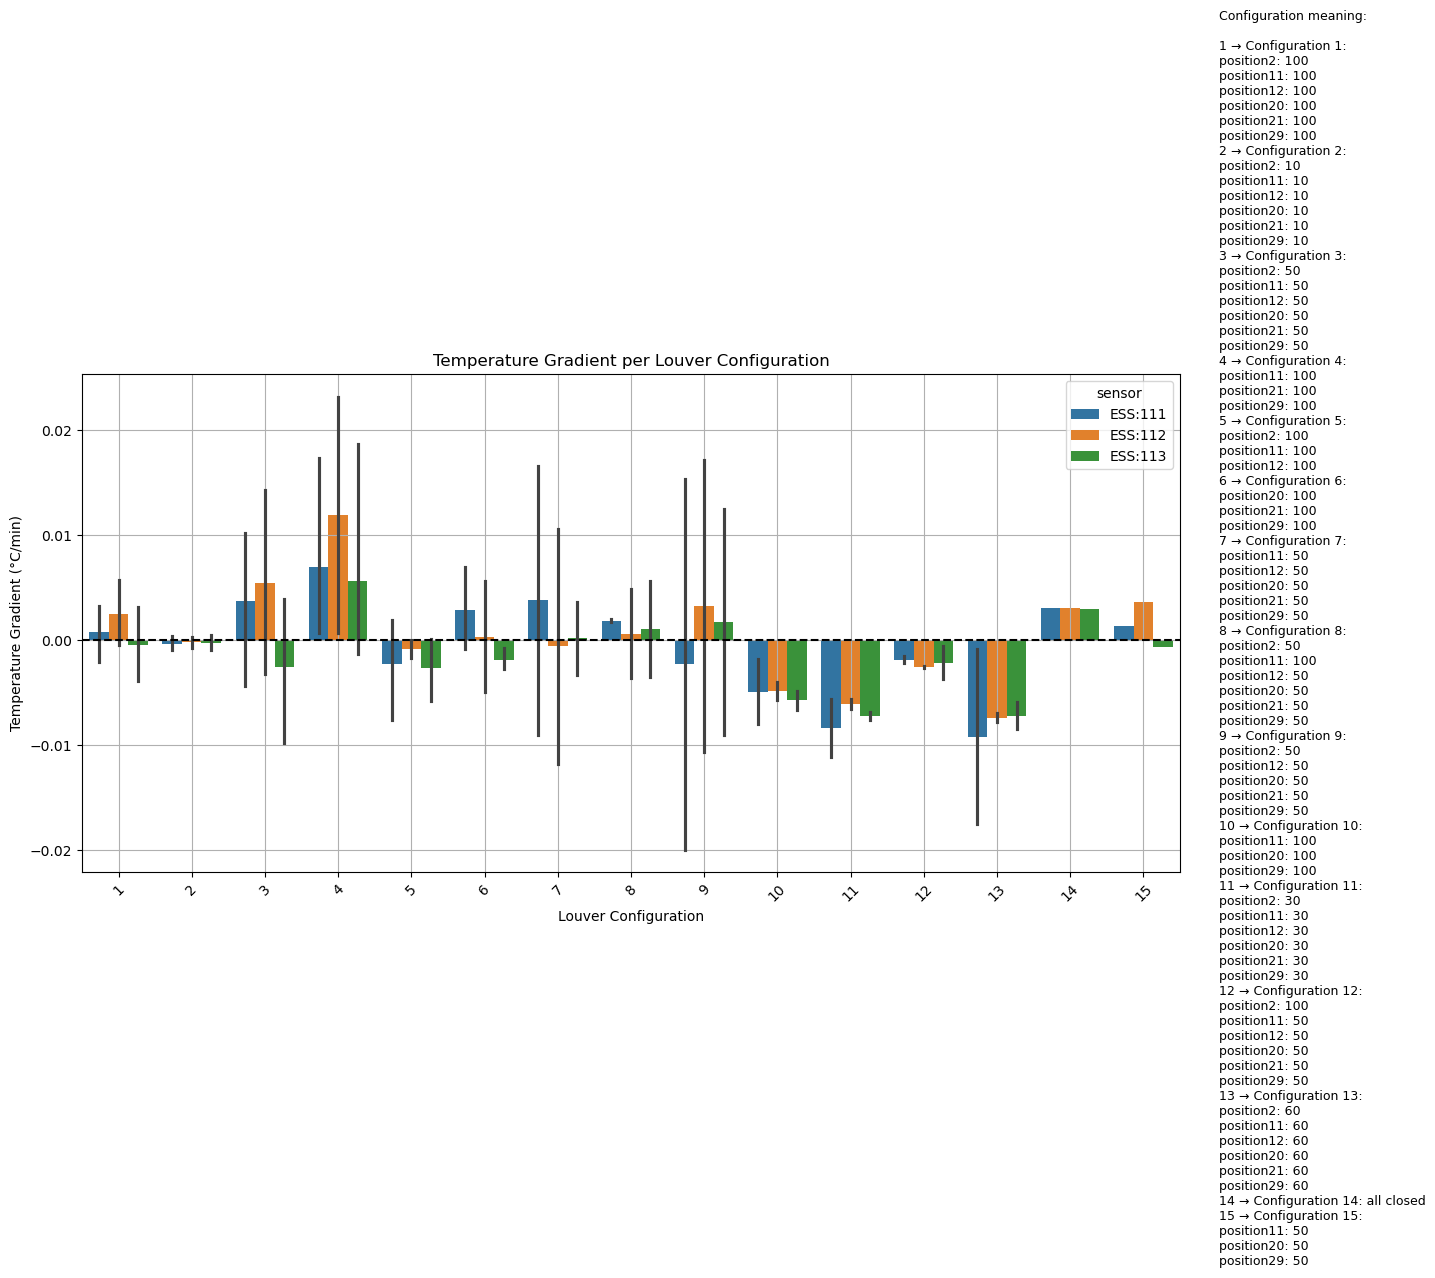

In [59]:
# Temperature Gradient per Louver Configuration
# Positive values indicate temperature increase, negative values indicate cooling

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_stats,
    x="louvers_conf",
    y="gradient_deg_per_min",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Temperature Gradient (°C/min)")
plt.title("Temperature Gradient per Louver Configuration")
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--')


# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)

plt.grid(True)
plt.tight_layout()
plt.show()

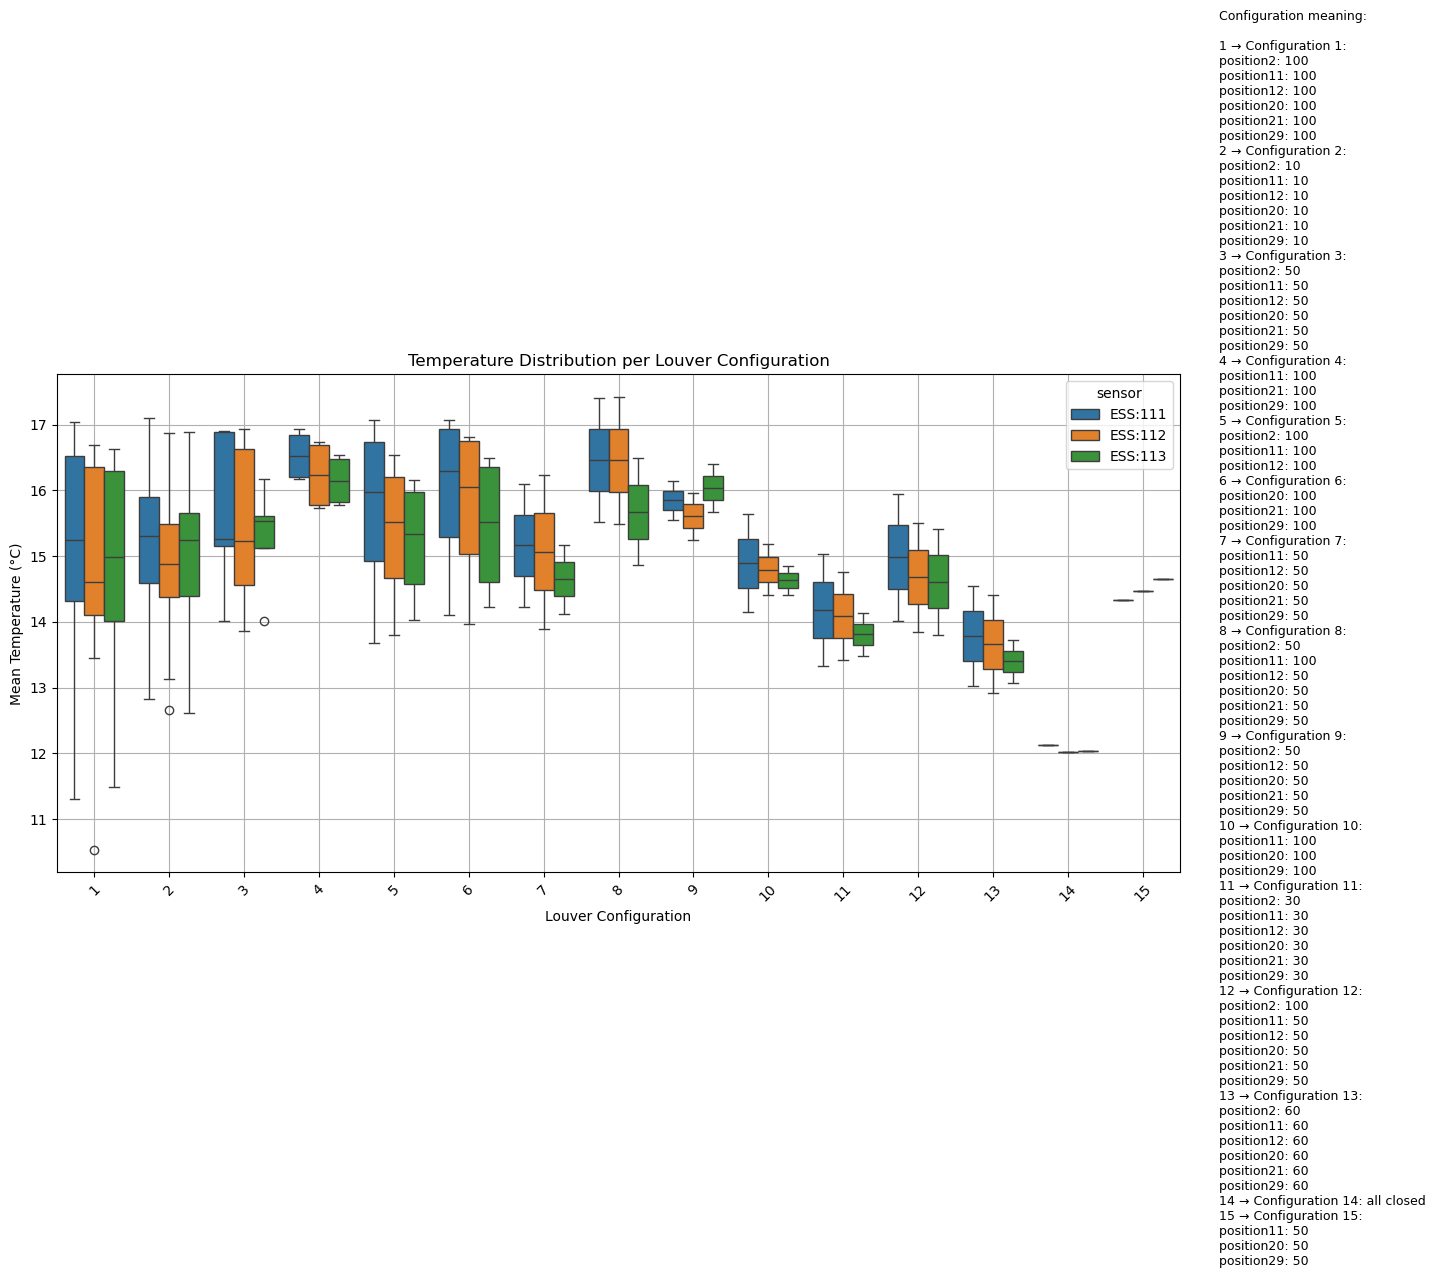

In [60]:
# Temperature Distribution per Louver Configuration
# Shows variability and outliers across repeated occurrences

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_stats,
    x="louvers_conf",
    y="mean_temp",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Mean Temperature (°C)")
plt.title("Temperature Distribution per Louver Configuration")
plt.xticks(rotation=45)

# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)


plt.grid(True)
plt.tight_layout()
plt.show()

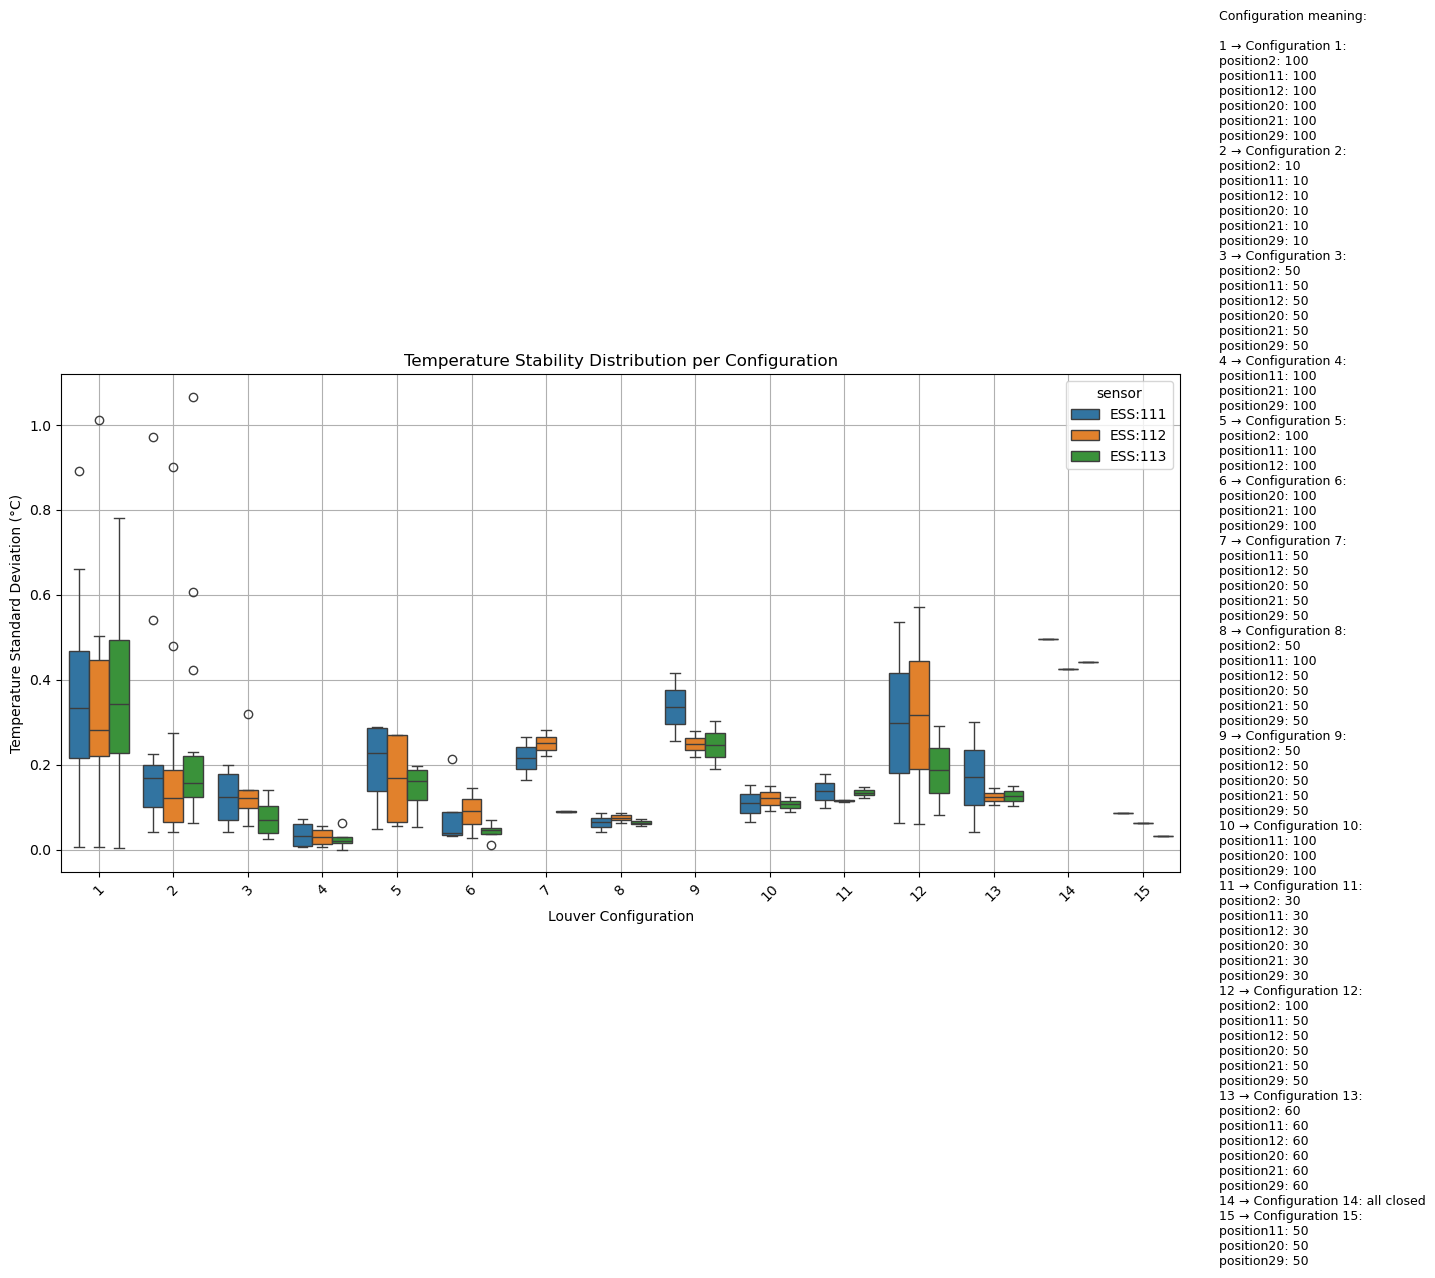

In [61]:
# Temperature Stability Distribution per Configuration
# Compares temperature variability across configurations

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_stats,
    x="louvers_conf",
    y="std_temp",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Temperature Standard Deviation (°C)")
plt.title("Temperature Stability Distribution per Configuration")
plt.xticks(rotation=45)

# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)

plt.grid(True)
plt.tight_layout()
plt.show()

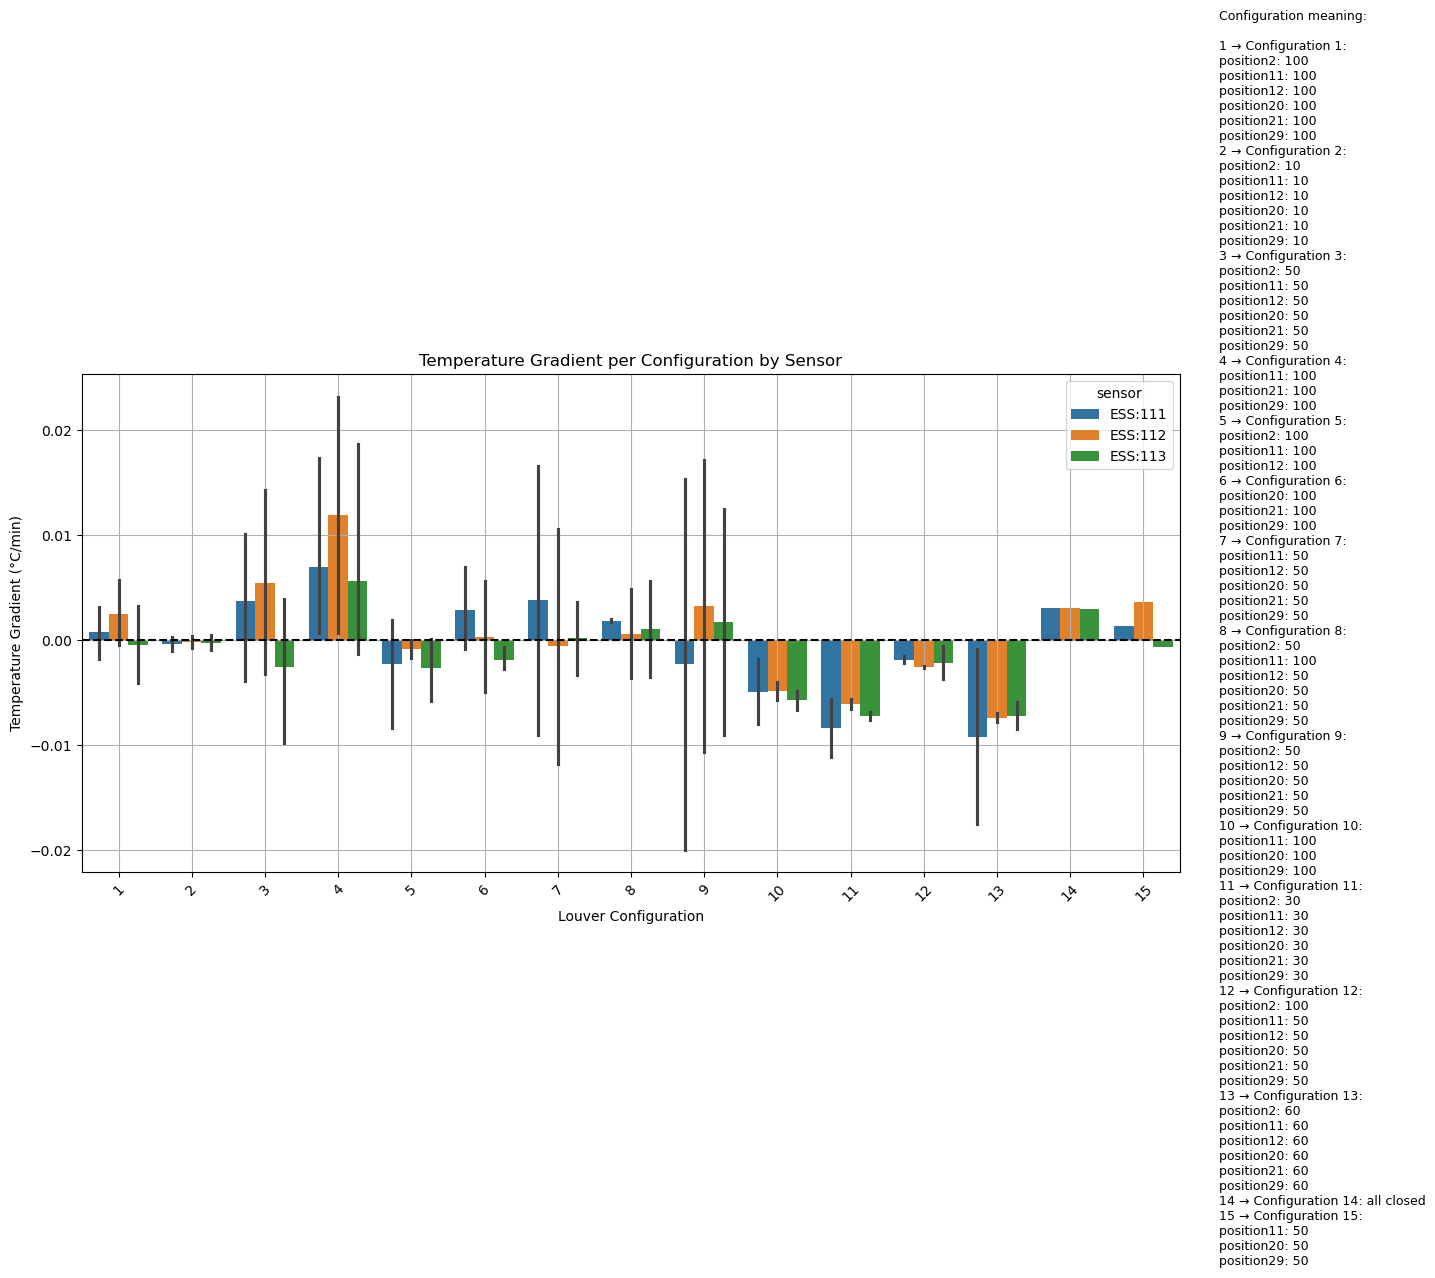

In [54]:
# Temperature Gradient per Configuration by Sensor
# Allows comparison of heating/cooling trends among sensors

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_stats,
    x="louvers_conf",
    y="gradient_deg_per_min",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Temperature Gradient (°C/min)")
plt.title("Temperature Gradient per Configuration by Sensor")

plt.axhline(0, color="black", linestyle="--")
plt.xticks(rotation=45)

plt.grid(True)

# ---- Create configuration legend text ----
conf_map = df_setlouvers[['louvers_conf','conf_label']].drop_duplicates().sort_values('louvers_conf')

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add text on the right side of the plot ----
plt.gcf().text(
    1.02,          # horizontal position (outside plot)
    0.5,           # vertical center
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va='center'
)

plt.tight_layout()
plt.show()

####*********** SUCIO*****

In [ ]:
def query_thermal(start, end):
    df_thermal = getEfdData(
        client=efd_client,
        topic="lsst.sal.MTDome.thermal",
        columns=["*"],
        begin=start,
        end=end,
    )

    return df_thermal

In [ ]:
df_thermal = query_thermal(t_start_period, t_end_period)

In [ ]:
df_thermal.head()

In [ ]:
df.columns

In [ ]:
# Make sure time columns are datetime (if not already)
df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'])
df_thermal['timestamp'] = pd.to_datetime(df_thermal['timestamp'])

# Sort both dataframes by time
df_setlouvers = df_setlouvers.sort_values('time_stamp')
df_thermal = df_thermal.sort_values('timestamp')

In [ ]:
# Perform temporal merge
df_thermal_with_conf = pd.merge_asof(
    df_thermal,
    df_setlouvers[['time_stamp', 'louvers_conf']],
    left_on='timestamp',
    right_on='time_stamp',
    direction='backward'  # take last known configuration
)

In [ ]:
def query_weather(start, end):
    df_weather = getEfdData(
        client=efd_client,
        topic="lsst.sal.WeatherForecast.dailyTrend",
        columns=["Max temperature", "temperatureMin", "Mean temperature", ],
        begin=start,
        end=end,
    )

    return df_weather

In [ ]:
df = query_weather(t_start_period, t_end_period)

## *****************************

In [ ]:
# Esto debe tener demasiado datos y no carga ni cambiando las fechas
def logevent_louversEnabled(start, end):
    df_louvers = getEfdData(
        client=efd_client,
        topic="lsst.sal.MTDome.louvers",
        columns=["*"],
        begin=start,
        end=end,
    )

    return df_louvers

In [ ]:
df = logevent_louversEnabled(t_start_period, t_end_period)

In [ ]:
df

In [ ]:
## Insert here the dayObs of interest
dayObs = 20260208# 20231122

In [ ]:
# Select data from a given date
eventMaker = TMAEventMaker()
events = eventMaker.getEvents(dayObs)


# Get events related to soak tests (block 137 currently)
blockT679 = []
for event in events:
    blockInfos = event.blockInfos
    if blockInfos is None:
        continue  # no block info attached to event at all

    # check if any of the attached blockInfos are for block 137
    blockNums = {b.blockNumber for b in blockInfos}
    print(blockNums)
    if T679 in blockNums:
        blockT679.append(event)

print(f"Of the {len(events)} events, {len(blockT679)} relate to block BLOCK-T679.")

In [ ]:
from lsst.summit.utils.blockUtils import BlockParser
from lsst.summit.utils.tmaUtils import TMAEventMaker

In [ ]:
# Set the day_obs list 
day_obs_list = range(20250127, 20260215 + 1)

# For the TMA events 
event_maker = TMAEventMaker()

In [ ]:
# For each day_obs in the list determine which blocks were run and put
# the list of blocks into the block_list.
 
block_list = []

for day_obs in day_obs_list:
    block_parser = BlockParser(day_obs)
    blocks = block_parser.getBlockNums()
    block_list.append(blocks)

# Put the variable length nested list into an awkward array and then 
# put that into a pandas dataframe with the awkward array extension
# so that the list of blocks is shown in a column.
blocks = ak.Array({"day_obs": day_obs_list, "blocks": block_list})
series = akpd.from_awkward(blocks)
pandas_df = series.ak.to_columns(extract_all=True)
pandas_df

In [ ]:
def day_obs_report(day_obs):
    '''
    Loop over the blocks and sequences for one day and produce a report.
    Interspace TMA events with the block info.
    '''

    block_parser = BlockParser(day_obs)
    tma_events = event_maker.getEvents(day_obs)
    blocks = block_parser.getBlockNums()

    print(f'SUMMARY REPORT FOR DAYOBS: {day_obs} \n')
    print(blocks)
    for block_id in blocks:
        sequences =  block_parser.getSeqNums(block_id)

        print(f'BLOCK:SEQ \t STATES')

        for seq_id in sequences:
            info = block_parser.getBlockInfo(block_id, seq_id)
            state_string = ' '.join([str(state) for state in info.states])
            print(f'{info.blockNumber}:{info.seqNum} \t\t {state_string}')

            # Also print any TMA events for this block/sequence
            event = block_parser.getEventsForBlock(tma_events, block_id, seq_id)
            if event: print(event)

        print(f'\n')

In [ ]:
day_obs_list = range(20260201, 20260214 + 1)

for day_obs in day_obs_list:
    day_obs_report(day_obs)